In [1]:
import warnings
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Tuple, List, Optional
from abc import ABC, abstractmethod

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from category_encoders import CountEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.tree import (
    DecisionTreeClassifier,
)
from sklearn import tree
import graphviz
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import xgboost as xgb
import time
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
RANDOM_STATE: int = 42

| Item          | Version  |
|-------------------|---------|
| Kernel            | Python 3.12.0 |
| sklearn           | 1.7.1   |
| pandas            | 2.3.2   |
| seaborn           | 0.13.2  |
| matplotlib        | 3.10.6  |
| code formatter    | black 25.1.0  |

In [2]:
notebook_time = time.time()

#### 1. Download data from Don’tGetKicked competition.

kaggle competitions download -c DontGetKicked<br>
or direct download

##### 1.1 Read all the data

In [3]:
path: str = "data/DontGetKicked/{name}.csv"
train_df: pd.DataFrame = pd.read_csv(path.format(name="training"), parse_dates=["PurchDate"])
test_df: pd.DataFrame = pd.read_csv(path.format(name="test"), parse_dates=["PurchDate"])

##### 1.2 Drop columns with N/A > 50%

In [4]:
NA_THRESHOLD: float = 0.5
NA_percent = train_df.isnull().mean()
to_drop = NA_percent[NA_percent >= NA_THRESHOLD].index
train_df_wo_na = train_df.drop(columns=to_drop)

##### 1.3 Simple impute N/A for other columns and scale numeric

In [5]:
TARGET: str = "IsBadBuy"
DATETIME_COL: str = "PurchDate"
numeric = (
    train_df_wo_na.drop(TARGET, axis=1)
    .select_dtypes(exclude=["object", "datetime"])
    .columns
)

categories = train_df_wo_na.select_dtypes(include="object").columns

numeric_pipeline = Pipeline(
    [
        ("num_imp", SimpleImputer(strategy="median")),
        ("st_scaler", StandardScaler()),
    ]
)

categories_pipeline = Pipeline(
    [
        ("cat_imp", SimpleImputer(strategy="constant", fill_value="unknown")),
    ]
)

col_tr = ColumnTransformer(
    transformers=[
        ("num_pipeline", numeric_pipeline, numeric),
        ("cat_pipeline", categories_pipeline, categories),
    ],
    remainder="drop",
)
train_df_tform_arr = col_tr.fit_transform(train_df_wo_na)

train_df_tform = pd.DataFrame(train_df_tform_arr)
train_df_tform.columns = numeric.to_list() + categories.to_list()
# add target and datetime col to final df
train_df_tform[DATETIME_COL] = train_df_wo_na[DATETIME_COL]
train_df_tform[TARGET] = train_df_wo_na[TARGET]

##### 1.4 Design the train/validation/test split. <br>Use the "PurchDate" field for the split, test must be later than validation, same for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate. <br>Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set. Don’t use the test dataset until the end!

In [6]:
def split_by_date_percentiles(
    X: pd.DataFrame,
    shift: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    info = X.dtypes
    date_in_df = [pd.api.types.is_datetime64_ns_dtype(x) for x in info.values]
    if not any(date_in_df):
        raise ValueError("No date col in df")

    date_col = info.index[date_in_df.index(True)]

    X = X.sort_values(by=date_col)

    unique_dates = X[date_col].unique()
    n_dates = len(unique_dates)

    train_threshold = unique_dates[n_dates // 3 + shift]
    val_threshold = unique_dates[2 * n_dates // 3 + shift]

    X_train = X[X[date_col] <= train_threshold]
    X_valid = X[(X[date_col] > train_threshold) & (X[date_col] <= val_threshold)]
    X_test = X[X[date_col] > val_threshold]

    assert X_train[date_col].max() < X_valid[date_col].min()
    assert X_valid[date_col].max() < X_test[date_col].min()

    return X_train, X_valid, X_test


def check_split(df_list: List[pd.DataFrame], df_initial: pd.DataFrame) -> None:
    final_set: set = set(df_initial.index)
    for df in df_list:
        final_set -= set(df.index)
    print(final_set == set())
    [print(round(len(x) / len(df_initial), 2), end=" ") for x in df_list]


X_train, X_valid, X_test = split_by_date_percentiles(train_df_tform, shift=8)
check_split(df_list=[X_train, X_valid, X_test], df_initial=train_df_tform)

True
0.33 0.33 0.33 

##### 1.5 Use LabelEncoder or OneHotEncoder from sklearn to preprocess categorical variables.<br> Be careful with data leakage (fit Encoder to training and apply to validation & test).<br> Consider another coding approach if you encounter new categorical values in validation & test (not seen in training):<br> https://contrib.scikit-learn.org/category_encoders/count.html

In [7]:
cat_to_onehot_enc: list = []
cat_to_count_enc: list = []

for category in categories:
    # if there is many unique values we cant use OHE
    if X_train[category].value_counts().count() < 21:
        cat_to_onehot_enc.append(category)
    else:
        cat_to_count_enc.append(category)

# to avoid dummy variable trap use drop='first'
# when feature matrix becomes singular (determinant = 0)
one_hot_enc = OneHotEncoder(
    sparse_output=False,
    drop="first",
    feature_name_combiner="concat",
    handle_unknown="ignore",
)
cat_one_hot_enc = one_hot_enc.fit(X_train[cat_to_onehot_enc])

count_enc = CountEncoder(normalize=True, min_group_size=15)
cat_count_enc = count_enc.fit(X_train[cat_to_count_enc])

df_transformed: list = []

for df in [X_train, X_valid, X_test]:
    cat_one_hot_enc = one_hot_enc.transform(df[cat_to_onehot_enc])
    cat_one_hot_enc = pd.DataFrame(
        cat_one_hot_enc, columns=one_hot_enc.get_feature_names_out()
    )

    cat_count_enc = count_enc.transform(df[cat_to_count_enc])
    combined = pd.concat(
        [
            df[numeric].reset_index(drop=True),
            cat_count_enc.reset_index(drop=True),
            cat_one_hot_enc.reset_index(drop=True),
            df[TARGET].reset_index(drop=True),
        ],
        axis=1,
    )
    df_transformed.append(combined)

X_train, X_valid, X_test = df_transformed

In [8]:
y_train = X_train[TARGET]
X_train = X_train.drop(TARGET, axis=1).astype(np.float64)
y_valid = X_valid[TARGET]
X_valid = X_valid.drop(TARGET, axis=1).astype(np.float64)
y_test = X_test[TARGET]
X_test = X_test.drop(TARGET, axis=1).astype(np.float64)

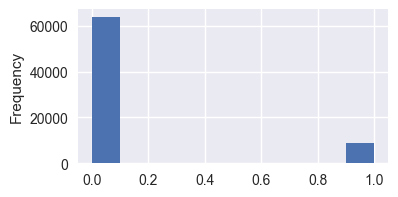

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 2))
train_df[TARGET].plot.hist(ax=ax)
fig.show()

Target classes are imbalanced

In [10]:
def gini_score_sk(y_true, y_score):
    """using 2*ROC AUC - 1 approach"""
    return round(2 * roc_auc_score(y_true=y_true, y_score=y_score) - 1, 4)

#### 2. Create a Python class for Decision Tree Classifier and Decision Tree Regressor (MSE loss).
It should support fit, predict_proba, and predict methods. <br>
Also, the maximum depth (max_depth) must be a parameter of your class.<br> 
Use the Gini impurity criterion as a criterion for choosing the split.

- Create a separate class for Node. It should be able to hold data (sample features and targets),<br> compute Gini impurity, and have pointers to children (left and right nodes). <br>For the Regressor, use variance (MSE loss) instead of Gini impurity.
- Implement a function that finds the best possible split in the current node.
- Combine the previous steps into your working Decision Tree Classifier.
- Implement an Extra Randomized Tree by designing another function to find the best split.

In [11]:
@dataclass
class Node:
    feature: Optional[int] = None
    threshold: Optional[float] = None
    left: Optional["Node"] = None
    right: Optional["Node"] = None
    value: Optional[int] = None
    gain: Optional[float] = None
    class_distribution: Optional[np.ndarray] = None

    @staticmethod
    def gini_impurity(y, classes):
        if len(y) == 0:
            return 0.0
        probs = np.bincount(y, minlength=len(classes)) / len(y)
        return 1.0 - np.sum(probs**2)

    @staticmethod
    def var(y):
        return np.var(y) if len(y) > 0 else 0.0

    @staticmethod
    # to substitute implementing Extra Randomized Tree
    def entropy(y, classes):
        if len(y) == 0:
            return 0.0
        probs = np.bincount(y, minlength=len(classes)) / len(y)
        probs = probs[probs > 0]
        return -np.sum(probs * np.log2(probs))

In [12]:
@dataclass
class BaseDecisionTree(ABC):
    max_depth: Optional[int] = None
    min_samples_split: int = 2
    min_samples_leaf: int = 1
    max_features: Optional[str] = None
    random_state: int = 42
    root: Optional[Node] = None

    def __post_init__(self):
        self.rng = np.random.default_rng(self.random_state)

    def build_tree(self, X, y, depth=0):
        n_samples = len(y)
        node_value = self.calc_node_value(y)
        class_distribution = (
            self.calc_cls_distribution(y)
            if hasattr(self, "calc_cls_distribution")
            else None
        )

        if (
            self.max_depth is not None
            and depth >= self.max_depth
            or n_samples < self.min_samples_split
            or len(np.unique(y)) == 1
        ):
            return Node(value=node_value, class_distribution=class_distribution)

        feature, threshold, gain = self.best_split(X, y)

        if feature is None or gain <= 0:
            return Node(value=node_value, class_distribution=class_distribution)

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        left_node = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_node = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(
            value=None,
            feature=feature,
            threshold=threshold,
            left=left_node,
            right=right_node,
            gain=gain,
            class_distribution=class_distribution,
        )

    @abstractmethod
    def calc_node_value(self, y):
        pass

    def best_split(self, X, y):
        n_samples, n_features = X.shape
        best_feature, best_threshold, best_gain = None, None, -1.0
        parent_crit = self.calc_crit(y)

        if parent_crit < 1e-12:
            return best_feature, best_threshold, best_gain

        feature_indices = self.get_feature_subset(n_features)

        for feature_idx in feature_indices:
            # Sorting by feature for efficient threshold search
            feature_values = X[:, feature_idx]
            sorted_indices = np.argsort(feature_values)
            sorted_features = feature_values[sorted_indices]
            sorted_y = y[sorted_indices]

            thresholds = self.get_thresholds(sorted_features)

            for threshold in thresholds:
                left_mask = sorted_features <= threshold
                right_mask = ~left_mask
                y_left = sorted_y[left_mask]
                y_right = sorted_y[right_mask]

                if (
                    len(y_left) >= self.min_samples_leaf
                    and len(y_right) >= self.min_samples_leaf
                ):
                    p = len(y_left) / len(y)
                    gain = (
                        parent_crit
                        - p * self.calc_crit(y_left)
                        - (1 - p) * self.calc_crit(y_right)
                    )

                    if gain > best_gain:
                        best_gain = gain
                        best_feature = feature_idx
                        best_threshold = threshold

        return best_feature, best_threshold, best_gain

    @abstractmethod
    def calc_crit(self, y):
        pass

    def get_feature_subset(self, n_features):
        if self.max_features == "sqrt":
            max_features = int(np.sqrt(n_features))
        elif self.max_features == "log2":
            max_features = int(np.log2(n_features)) + 1
        elif self.max_features is None:
            max_features = n_features
        else:
            max_features = self.max_features

        max_features = max(1, min(max_features, n_features))
        return self.rng.choice(n_features, size=max_features, replace=False)

    @abstractmethod
    def get_thresholds(self, sorted_features):
        pass

    def _traverse_to_leaf(self, x):
        node = self.root
        while node.value is None:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node

In [13]:
@dataclass
class DecisionTreeClsf(BaseDecisionTree):
    criterion: str = "gini"
    classes_: Optional[np.ndarray] = None

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y).astype(int)
        self.classes_ = np.unique(y)
        self.root = self.build_tree(X, y)

    def calc_node_value(self, y):
        # func mode
        return (
            np.argmax(np.bincount(y, minlength=len(self.classes_))) if len(y) > 0 else 0
        )

    def calc_cls_distribution(self, y):
        counts = np.bincount(y, minlength=len(self.classes_))
        return counts / len(y)

    def calc_crit(self, y):
        if self.criterion == "gini":
            return Node.gini_impurity(y, self.classes_)
        return Node.entropy(y, self.classes_)

    def get_thresholds(self, sorted_features):
        # naive approach
        return np.unique(sorted_features)

    def predict_proba(self, X):
        X = np.asarray(X)
        proba = np.zeros((len(X), len(self.classes_)))
        for i, x in enumerate(X):
            leaf = self._traverse_to_leaf(x)
            proba[i] = leaf.class_distribution
        return proba

    def predict(self, X):
        indices = np.argmax(self.predict_proba(X), axis=1)
        return self.classes_[indices]

In [14]:
@dataclass
class DecisionTreeRegressor(BaseDecisionTree):
    n_thresholds: int = 50

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).astype(float)
        self.root = self.build_tree(X, y)

    def calc_node_value(self, y):
        return np.mean(y) if len(y) > 0 else 0.0

    def calc_crit(self, y):
        """variance (MSE loss)"""
        return np.var(y) if len(y) > 0 else 0.0

    def get_thresholds(self, sorted_features):
        # LightGBM, XGBoost and modern scikit-learn approach because
        # DTRegressor is 200+ times more expensive than DTClsf in our implementation
        # Clsf gini O(classes=2), Reg variance O(n_samples of node)
        if len(sorted_features) <= self.n_thresholds:
            return np.unique(sorted_features)
        percentiles = np.linspace(10, 90, self.n_thresholds)
        return np.percentile(sorted_features, percentiles)

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._traverse_to_leaf(x).value for x in X], dtype=float)

#### 3. With your DecisionTree module, you must obtain a Gini score of at least 0.1 on the validation dataset.

#### 4.  Use sklearn's DecisionTreeClassifier and check its performance on the validation dataset. Is it better than your module? If so, why?

In [15]:
best_depth, best_gini = 1, 0

for depth in range(1, 10):
    model = DecisionTreeClassifier(criterion="gini", random_state=42, max_depth=depth)
    model.fit(X=X_train, y=y_train)
    y_pred = model.predict_proba(X=X_valid)[:, 1]
    gini = gini_score_sk(y_true=y_valid, y_score=y_pred)
    if best_gini < gini:
        best_gini = gini
        best_depth = depth
        print(f"{depth = } {gini = }")

depth = 1 gini = 0.2344
depth = 2 gini = 0.3634
depth = 3 gini = 0.4331
depth = 4 gini = 0.4408
depth = 5 gini = 0.4544


At first gini improves then it can decrease due to overfitting

In [16]:
def calc_metrics_for_model(model, out: pd.DataFrame, model_name: str):
    start_time = time.time()

    if "catboost" in model_name.lower():
        catboost_train = Pool(X_train, label=y_train)
        catboost_valid = Pool(X_valid, label=y_valid)
        model.fit(
            catboost_train,
            eval_set=catboost_valid,
            early_stopping_rounds=100,
            verbose=False,
        )
    elif "xgb" in model_name.lower():
        X_valid_xgb = xgb.DMatrix(X_valid, label=y_valid)
        model = xgb.train(**model)
    elif "light" in model_name.lower():
        model = lgb.train(**model)
    else:
        model.fit(X=X_train, y=y_train)

    fit_time = round(time.time() - start_time, 4)
    start_time = time.time()

    if "xgb" in model_name.lower():
        y_pred = model.predict(data=X_valid_xgb)
    elif "light" in model_name.lower():
        y_pred = model.predict(data=X_valid)
    else:
        y_pred = model.predict_proba(X=X_valid)[:, 1]

    predict_time = round(time.time() - start_time, 4)
    out.loc[len(out)] = {
        "model": model.__class__.__name__ if not model_name else model_name,
        "Gini(X_valid)": gini_score_sk(y_true=y_valid, y_score=y_pred),
        "Fit_time": fit_time,
        "Predict_time": predict_time,
    }

In [17]:
out: pd.DataFrame = pd.DataFrame(
    {"model": [], "Gini(X_valid)": [], "Fit_time": [], "Predict_time": []}
)

for model, name in [
    (
        DecisionTreeClsf(
            criterion="gini",
            random_state=42,
            max_depth=best_depth,
            max_features=None,
        ),
        "My_DTC",
    ),
    # instead of implementing Extra Randomized Tree use this:
    (
        DecisionTreeClsf(
            criterion="entropy",
            random_state=42,
            max_depth=best_depth,
            max_features=None,
        ),
        "My_Extra_Rnd_DTC",
    ),
    (
        DecisionTreeClassifier(
            criterion="gini",
            random_state=42,
            max_depth=best_depth,
            max_features=None,
        ),
        "Sklearn_DTC",
    ),
]:
    calc_metrics_for_model(model=model, out=out, model_name=name)

out.reset_index(drop=True)

,model,Gini(X_valid),Fit_time,Predict_time
0,My_DTC,0.4524,35.2481,0.0405
1,My_Extra_Rnd_DTC,0.4356,38.4462,0.0425
2,Sklearn_DTC,0.4544,0.1714,0.0072


Is it better than your module? If so, why?<br>No significant diff because our implementation is close to sklearn

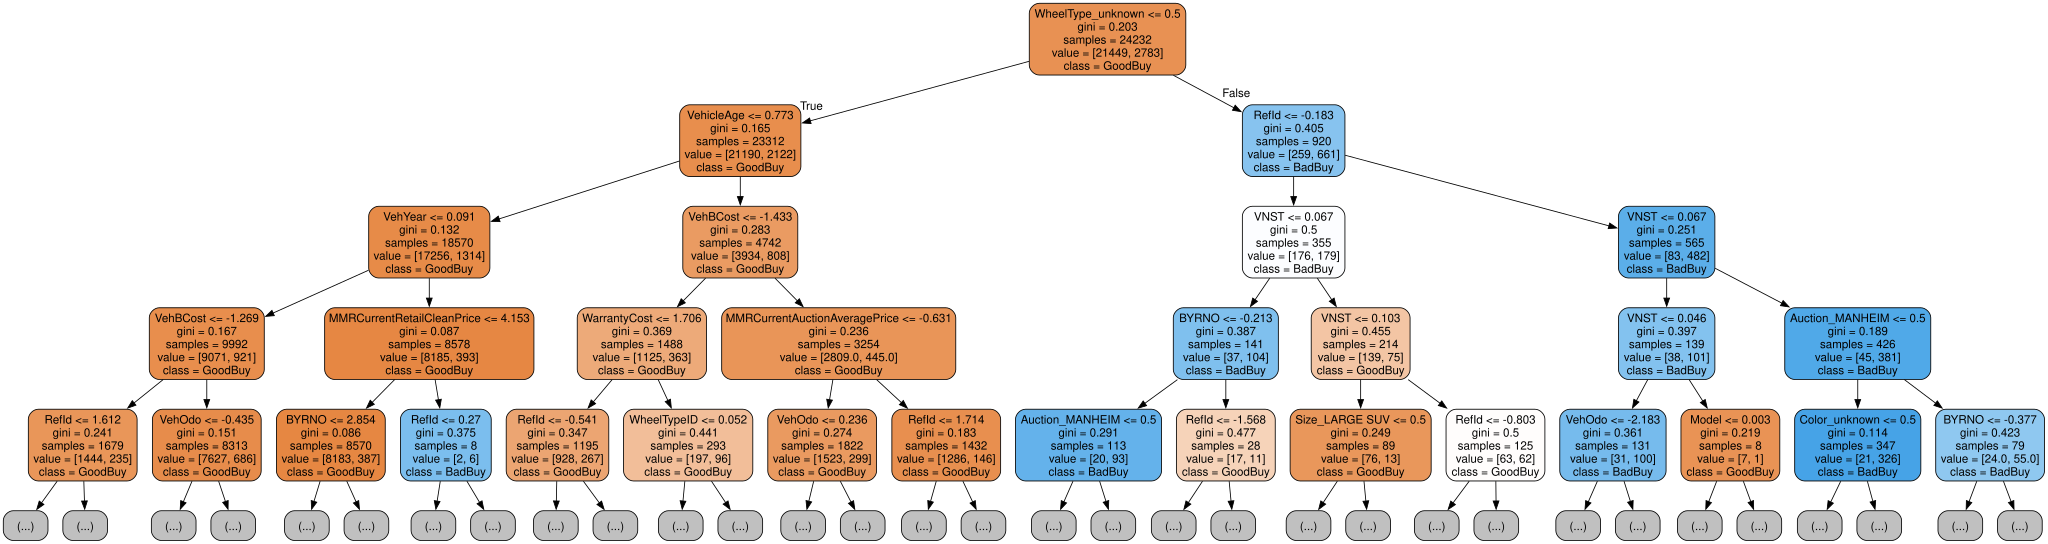

In [18]:
dot_data = tree.export_graphviz(
    decision_tree=model,
    max_depth=4,
    feature_names=model.feature_names_in_,
    class_names=["GoodBuy", "BadBuy"],
    filled=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

#### 5. Implement the RandomForestClassifier and check its performance. <br>You have to improve the result of a single tree and get at least 0.15 Gini score on the validation dataset. Be able to set a fixed random seed.

In [19]:
@dataclass
class RandomForestClsf:
    n_estimators: int = 100
    max_depth: Optional[int] = None
    criterion: str = "gini"
    random_state: int = 42
    min_samples_split: int = 2
    min_samples_leaf: int = 1
    max_features: Optional[str] = "sqrt"
    bootstrap: bool = True

    estimators_: List[DecisionTreeClsf] = field(default_factory=list)
    classes_: Optional[np.ndarray] = None
    n_features_: Optional[int] = None

    def __post_init__(self):
        self.rng = np.random.default_rng(self.random_state)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).astype(int)
        n_samples, self.n_features_ = X.shape
        self.classes_ = np.unique(y)
        self.estimators_ = []

        for i in range(self.n_estimators):
            bootstrap_indices = self.bootstrap_samples(n_samples)
            X_bootstrap = X[bootstrap_indices]
            y_bootstrap = y[bootstrap_indices]

            tree = DecisionTreeClsf(
                max_depth=self.max_depth,
                criterion=self.criterion,
                random_state=self.random_state + i,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features="sqrt",
            )

            tree.fit(X_bootstrap, y_bootstrap)
            self.estimators_.append(tree)

    def bootstrap_samples(self, n_samples):
        if self.bootstrap:
            indices = self.rng.choice(n_samples, size=n_samples, replace=True)
        else:
            indices = np.arange(n_samples)
        return indices

    def predict_proba(self, X):
        X = np.asarray(X)
        all_proba = np.zeros((len(self.estimators_), len(X), len(self.classes_)))

        for i, tree in enumerate(self.estimators_):
            all_proba[i] = tree.predict_proba(X)

        return np.mean(all_proba, axis=0)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

#### 6. Use your DecisionTree design class for GBDT classifier (Gradient Boosted Decision Trees Classifier).<br>This class must have max_depth, number_of_trees and max_features attributes.<br> You must compute the gradient of the binary cross-entropy loss function and implement incremental learning: train the next tree using the results of the previous trees.

In [20]:
@dataclass
class GBDT_Clsf:
    n_estimators: int = 100
    learning_rate: float = 0.1
    max_depth: int = 3
    min_samples_split: int = 2
    min_samples_leaf: int = 1
    random_state: int = 42
    trees: List[DecisionTreeRegressor] = field(default_factory=list)
    max_features: Optional[str] = None
    initial_prediction: Optional[float] = None

    def __post_init__(self):
        self.rng = np.random.default_rng(self.random_state)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        unique_classes = np.unique(y)
        if len(unique_classes) != 2:
            raise ValueError("GBDTClassifier only supports binary classification")

        self.initial_prediction = self.log_odds(y)
        current_predictions = np.full(len(y), self.initial_prediction, dtype=float)

        self.trees = []

        for i in range(self.n_estimators):
            current_probs = self.sigmoid(current_predictions)
            residuals = self.negative_gradient(y, current_probs)

            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                random_state=self.random_state + i,
                max_features=self.max_features,
            )

            tree.fit(X, residuals)

            tree_predictions = tree.predict(X)
            current_predictions += self.learning_rate * tree_predictions

            self.trees.append(tree)

    def log_odds(self, y):
        if len(y) == 0:
            return 0.0
        positive_count = np.sum(y == 1)
        # Simpler calculation with Laplace smoothing
        prob_positive = (positive_count + 1) / (len(y) + 2)
        return np.log(prob_positive / (1 - prob_positive))

    @staticmethod
    def sigmoid(x):
        # sigmoid(500) ≈ 1.0, sigmoid(-500) ≈ 0.0
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def negative_gradient(self, y, y_pred_proba):
        return y - y_pred_proba

    def predict_proba(self, X):
        X = np.asarray(X)
        predictions = np.full(X.shape[0], self.initial_prediction, dtype=float)

        for tree in self.trees:
            predictions += self.learning_rate * tree.predict(X)

        probabilities = self.sigmoid(predictions)

        return np.column_stack([1 - probabilities, probabilities])

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return (probabilities[:, 1] > 0.5).astype(int)

In [21]:
best_est, best_depth, best_gini = 1, 1, 0
for est in range(1, 101, 10):
    for depth in range(1, 10):
        model = RandomForestClassifier(
            n_estimators=est, criterion="gini", random_state=42, max_depth=depth
        )
        model.fit(X=X_train, y=y_train)
        y_pred = model.predict_proba(X=X_valid)[:, 1]
        gini = gini_score_sk(y_true=y_valid, y_score=y_pred)
        if best_gini < gini:
            best_gini = gini
            best_depth = depth
            best_est = est
            print(f"{est = } {depth = } {gini = }")

est = 1 depth = 1 gini = 0.0838
est = 1 depth = 2 gini = 0.1428
est = 1 depth = 3 gini = 0.2726
est = 1 depth = 4 gini = 0.3494
est = 1 depth = 5 gini = 0.3949
est = 11 depth = 1 gini = 0.4325
est = 11 depth = 2 gini = 0.4521
est = 11 depth = 3 gini = 0.4626
est = 11 depth = 4 gini = 0.463
est = 21 depth = 4 gini = 0.4702


In [22]:
for model, name in [
    (
        RandomForestClsf(
            n_estimators=best_est,
            criterion="gini",
            random_state=42,
            max_depth=best_depth,
            max_features="sqrt",
        ),
        "My_RandomForest",
    ),
    # instead of implementing ExtraTreesClassifier use this:
    (
        RandomForestClsf(
            n_estimators=best_est,
            criterion="entropy",
            random_state=42,
            max_depth=best_depth,
            max_features="sqrt",
        ),
        "My_ExtraTreesClassifier",
    ),
    (
        GBDT_Clsf(n_estimators=best_est, random_state=42, max_depth=best_depth),
        "My_GBDT_Clsf",
    ),
    (
        RandomForestClassifier(
            n_estimators=best_est,
            criterion="gini",
            random_state=42,
            max_depth=best_depth,
        ),
        "Sklearn_RandomForest",
    ),
]:
    calc_metrics_for_model(model=model, out=out, model_name=name)

out.reset_index(drop=True)

,model,Gini(X_valid),Fit_time,Predict_time
0,My_DTC,0.4524,35.2481,0.0405
1,My_Extra_Rnd_DTC,0.4356,38.4462,0.0425
2,Sklearn_DTC,0.4544,0.1714,0.0072
3,My_RandomForest,0.4585,42.5191,0.6983
4,My_ExtraTreesClassifier,0.4629,44.7541,0.6976
5,My_GBDT_Clsf,0.4639,43.0861,0.5350
6,Sklearn_RandomForest,0.4702,0.2615,0.0175


#### 7. Use LightGBM, Catboost, and XGBoost for fitting on a training set and prediction on a validation set.<br> Review the documentation of the libraries and fine-tune the algorithms for the task.<br> Note key differences between each implementation.<br> Analyze special features of each algorithm (how does "categorical feature" work in Catboost, what is DART mode in XGBoost)?<br> Which GBDT model gives the best result? Can you explain why?

| Criteria | XGBoost | LightGBM | CatBoost |
|----------|---------|-----------|----------|
| 1. Algorithm Complexity / Training Time | O(N * log N) - High<br>Uses pre-sorting and histograms | O(N) - Low<br>Uses Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB) | O(N) - Medium/Low<br>Efficient handling of categorical features without preprocessing |
| 2. Best Split Approach / Split Criterion | Pre-sorted Algorithm & Histogram<br>Finds best split by enumerating all possible points<br>More accurate but slower<br>Uses weighted variance | Histogram-based & Leaf-wise<br>Builds histograms for features<br>Selects split with max gain<br>Grows leaf-wise | Ordered Boosting & Oblivious Trees<br>Ordered boosting to fight bias<br>Oblivious trees - symmetric trees<br>Same splits per level |
| 3. Gradient Calculation Approach | Standard Gradient Boosting (1st and 2nd order)<br>Optimizes function using gradient and hessian<br>First and second derivatives | Standard Gradient Boosting (1st order)<br>Uses first derivatives<br>GOSS selects instances with large gradients | Ordered Boosting<br>Calculates gradient on model trained without object<br>Prevents target leakage |
| 4. Conceptual Difference in DT Regressor Implementation | Level-wise (Depth-wise) Growth<br>Tree grows level by level<br>Balanced but less accurate | Leaf-wise Growth<br>Grows by choosing leaf with max loss reduction<br>Deeper and more accurate but prone to overfitting | Oblivious Trees (Symmetric Trees)<br>Same splitting condition per level<br>Simplifies model and speeds prediction<br>Works well with categorical features |
| 5. GPU Support | Yes<br>Full support for training and inference | Yes<br>Full support for training and inference | Yes<br>Excellent support<br>Originally designed with GPU focus |
| 6. Categorical Features Handling | Requires preprocessing<br>One-hot encoding or ordinal encoding | Native support<br>Direct work with categories via histograms | Advanced processing<br>Ordered Target Statistics<br>Automatic category detection<br>No preprocessing needed |
| 7. Special Modes | DART (Dropouts meet Multiple Additive Regression Trees)<br>Dropout for trees like in neural networks<br>Reduces overfitting<br>Improves generalization | Gradient-based One-Side Sampling<br>Exclusive Feature Bundling<br>Optimizations for big data | Ordered Boosting<br>Efficient category handling<br>Text fields auto-encoding |
| 8. Other Significant Differences | - Built-in regularization (L1, L2)<br>- Missing value handling<br>- Wide language support | - GOSS and EFB for speed<br>- Supports large-scale data<br>- Good CPU performance | - Native categorical features handling<br>- Robust to overfitting<br>- Automatic text features handling |

LightGBM > XGBoost ≈ CatBoost (on data with categorical features) > XGBoost (on purely numerical data).

CatBoost uses innovative Ordered Target Statistics approach for categorical features:

- Automatic detection: Automatically recognizes categorical features
- Ordered Encoding: Uses ordered encoding based on target variable statistics
- Overfitting protection: For each object, calculates statistics only on preceding data
- No preprocessing: Doesn't require one-hot encoding or other transformations

DART (Dropouts meet Multiple Additive Regression Trees) - special mode in XGBoost:

- Tree dropout: Randomly excludes trees during ensemble building
- Neural networks analogy: Similar to dropout in neural networks
- Overfitting reduction: Helps combat overfitting in complex tasks
- Improved generalization: Enhances model performance on new data

Summary
- XGBoost offers a balance between performance and functionality
- LightGBM, a fast and efficient gradient boosting framework for large datasets
- CatBoost is unique in its ability to handle categorical data without the need for pre-encoding

 Russian version hidden below
<!-- | Критерий | XGBoost | LightGBM | CatBoost |
|----------|---------|-----------|----------|
| 1. Сложность алгоритма / Время обучения | O(N * log N) - Высокая<br>Использует предварительную сортировку и гистограммы | O(N) - Низкая<br>Использует Gradient-based One-Side Sampling (GOSS) и Exclusive Feature Bundling (EFB) | O(N) - Средняя/Низкая<br>Эффективная обработка категориальных признаков без предобработки |
| 2. Подход к Best Split / Критерий Split | Pre-sorted Algorithm & Histogram<br>Ищет лучший сплит перебором всех точек разбиения<br>Более точный но медленный<br>Использует взвешенную дисперсию | Histogram-based & Leaf-wise<br>Строит гистограммы для признаков<br>Выбирает сплит с максимальным выигрышем<br>Растет leaf-wise | Ordered Boosting & Oblivious Trees<br>Упорядоченное усиление против смещения<br>Oblivious trees - симметричные деревья<br>Одинаковые сплиты на уровне |
| 3. Подход вычисления градиента | Standard Gradient Boosting (1st and 2nd order)<br>Оптимизирует функцию используя градиент и гессиан<br>Первые и вторые производные | Standard Gradient Boosting (1st order)<br>Использует первые производные<br>GOSS выбирает объекты с большими градиентами | Ordered Boosting<br>Вычисляет градиент на модели обученной без объекта<br>Предотвращает утечку данных |
| 4. Концептуальная разница реализации Decision Tree Regressor | Level-wise (Depth-wise) Growth<br>Дерево растет по уровням<br>Сбалансированное но менее точное | Leaf-wise Growth<br>Растет выбирая лист с максимальным уменьшением потерь<br>Глубже и точнее но склонно к переобучению | Oblivious Trees (Symmetric Trees)<br>Одно условие разбиения на уровне<br>Упрощает модель и ускоряет предсказание<br>Хорошо с категориальными признаками |
| 5. Поддержка GPU | Да<br>Полная поддержка для обучения и предсказания | Да<br>Полная поддержка для обучения и предсказания | Да<br>Отличная поддержка<br>Изначально разработан с фокусом на GPU |
| 6. Обработка категориальных признаков | Требует предобработки<br>One-hot encoding или ординальное кодирование | Нативная поддержка<br>Прямая работа с категориями через гистограммы | Передовая обработка<br>Ordered Target Statistics<br>Автоматическое определение категорий<br>Без предобработки |
| 7. Специальные режимы | DART (Dropouts meet Multiple Additive Regression Trees)<br>Дропаут для деревьев как в нейросетях<br>Уменьшает переобучение<br>Улучшает обобщающую способность | Gradient-based One-Side Sampling<br>Exclusive Feature Bundling<br>Оптимизации для больших данных | Ordered Boosting<br>Эффективная работа с категориями<br>Автокодирование текстовых полей |
| 8. Другие значимые отличия | - Встроенная регуляризация (L1, L2)<br>- Обработка пропущенных значений<br>- Широкий язык поддержки | - GOSS и EFB для ускорения<br>- Поддержка больших датасетов<br>- Хорошая производительность на CPU | - Нативная обработка категориальных признаков<br>- Устойчивость к переобучению<br>- Автоматическая обработка текстовых признаков |

CatBoost использует инновационный подход Ordered Target Statistics для обработки категориальных признаков:

- Автоматическое определение: CatBoost автоматически распознает категориальные признаки
- Ordered Encoding: Использует упорядоченное кодирование на основе статистик целевой переменной
- Защита от переобучения: Для каждого объекта вычисляет статистику только на предшествующих данных
- Без предобработки: Не требует one-hot encoding или других преобразований


DART (Dropouts meet Multiple Additive Regression Trees) - специальный режим в XGBoost:

- Дропаут деревьев: Случайным образом исключает деревья при построении ансамбля
- Аналогия с нейросетями: Похож на dropout в нейронных сетях
- Уменьшение переобучения: Помогает бороться с переобучением в сложных задачах
- Улучшение обобщения: Повышает способность модели работать на новых данных -->

##### 7.1 LightGBM (Light Gradient-Boosting Machine) by Microsoft (core C++, API: Python, R, C, C#)

In [23]:
test_learning_rates: list = [0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05, 0.075, 0.1]
test_num_leaves: list = [5, 10, 15, 20, 31, 63]
test_max_depth: range = range(2, 8)

# naive fine tune
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_valid = lgb.Dataset(X_valid, label=y_valid, reference=lgb_train)

# from documentation
base_params: dict = {
    "objective": "binary",
    "metric": ["binary_logloss", "auc"],
    "num_leaves": 20,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
}

best_params, test_gini = {}, 0

for lr in test_learning_rates:
    current_params = base_params.copy()
    current_params["learning_rate"] = lr
    for leaf in test_num_leaves:
        current_params["num_leaves"] = leaf

        model = lgb.train(
            current_params,
            lgb_train,
            num_boost_round=1000,
            valid_sets=[lgb_valid],
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
        )

        y_pred = model.predict(X_valid)
        cur_gini = gini_score_sk(y_true=y_valid.values, y_score=y_pred)
        if cur_gini > test_gini:
            best_params = current_params.copy()
            test_gini = cur_gini

In [24]:
lgbm_final_params: dict = {
    "params": best_params,
    "train_set": lgb_train,
    "num_boost_round": 1000,
    "valid_sets": [lgb_valid],
    "valid_names": ["validation"],
    "callbacks": [
        lgb.early_stopping(100, verbose=False),
        lgb.log_evaluation(0),
    ],
}

calc_metrics_for_model(model=lgbm_final_params, out=out, model_name="LightGBM")

##### 7.2 CatBoost by Yandex (core C++, API: Python, R)

In [25]:
# naive fine tune
catboost_train = Pool(X_train, label=y_train)
catboost_valid = Pool(X_valid, label=y_valid)

base_params: dict = {
    "eval_metric": "AUC",
    "leaf_estimation_iterations": 10,
    "random_seed": 42,
    "verbose": False,
    "early_stopping_rounds": 100,
}

best_params, test_gini = {}, 0

for lr in test_learning_rates:
    current_params = base_params.copy()
    current_params["learning_rate"] = lr

    for depth in test_max_depth:
        current_params["max_depth"] = depth

        model = CatBoostClassifier(**current_params)

        model.fit(
            catboost_train,
            eval_set=catboost_valid,
            early_stopping_rounds=100,
            verbose=False,
        )

        y_pred = model.predict_proba(X_valid)[:, 1]
        cur_gini = gini_score_sk(y_true=y_valid.values, y_score=y_pred)

        if cur_gini > test_gini:
            best_params = current_params.copy()
            test_gini = cur_gini

In [26]:
CatBoost_model = CatBoostClassifier(**best_params)
calc_metrics_for_model(model=CatBoost_model, out=out, model_name="CatBoost")

##### 7.3 XGBoost by The XGBoost Contributors (core C++, API: Python, R, Java, Julia, Scala and etc)

In [27]:
# naive fine tune
xgb_train = xgb.DMatrix(X_train, label=y_train)
xgb_valid = xgb.DMatrix(X_valid, label=y_valid)

base_params: dict = {
    "objective": "binary:logistic",
    "eval_metric": ["logloss", "auc"],
    "max_depth": 6,
    "subsample": 0.8,  # like bagging_fraction
    "colsample_bytree": 0.9,  # like feature_fraction
    "eta": 0.1,  # like learning_rate
    "seed": 42,
    "verbosity": 0,
}

best_params, test_gini = {}, 0

for lr in test_learning_rates:
    current_params = base_params.copy()
    current_params["eta"] = lr

    for depth in test_max_depth:
        current_params["max_depth"] = depth

        model = xgb.train(
            current_params,
            xgb_train,
            num_boost_round=1000,
            evals=[(xgb_valid, "valid")],
            early_stopping_rounds=100,
            verbose_eval=False,
        )

        y_pred = model.predict(xgb_valid)
        cur_gini = gini_score_sk(y_true=y_valid.values, y_score=y_pred)

        if cur_gini > test_gini:
            best_params = current_params.copy()
            test_gini = cur_gini

In [28]:
xgb_final_params: dict = {
    "params": best_params,
    "dtrain": xgb_train,
    "num_boost_round": 1000,
    "evals": [(xgb_valid, "valid")],
    "early_stopping_rounds": 100,
    "verbose_eval": False,
}
calc_metrics_for_model(model=xgb_final_params, out=out, model_name="XGBoost")
out.reset_index(drop=True)

,model,Gini(X_valid),Fit_time,Predict_time
0,My_DTC,0.4524,35.2481,0.0405
1,My_Extra_Rnd_DTC,0.4356,38.4462,0.0425
2,Sklearn_DTC,0.4544,0.1714,0.0072
3,My_RandomForest,0.4585,42.5191,0.6983
4,My_ExtraTreesClassifier,0.4629,44.7541,0.6976
5,My_GBDT_Clsf,0.4639,43.0861,0.5350
6,Sklearn_RandomForest,0.4702,0.2615,0.0175
7,LightGBM,0.4910,2.0161,0.0836
8,CatBoost,0.4898,2.7440,0.0000
9,XGBoost,0.4937,1.1604,0.0151


#### 8. Take the best model and estimate its performance on the test dataset:<br>check the Gini values on all three datasets for your best model: training Gini, valid Gini, test Gini.<br>Do you see a drop in performance when comparing the valid quality to the test quality? Is your model overfitting or not? Explain.

In [29]:
# best models
LightGBM_model = lgb.train(**lgbm_final_params)
XGB_model = xgb.train(**xgb_final_params)

f_out: dict = {
    "Model": ["LightGBM", "CatBoost", "XGBoost"],
    "Train_Gini": [],
    "Valid_Gini": [],
    "Test_Gini": [],
    "Train –> Valid diff, %": [],
    "Valid –> Test diff, %": [],
}

for num, model in enumerate((LightGBM_model, CatBoost_model, XGB_model)):

    for x, y, name in (
        (X_train, y_train, "Train"),
        (X_valid, y_valid, "Valid"),
        (X_test, y_test, "Test"),
    ):

        if "cat" in str(model):
            y_pred = model.predict_proba(X=x)[:, 1]
        elif "xgb" in str(model):
            x = xgb.DMatrix(x, label=y)
            y_pred = model.predict(data=x)
        else:
            y_pred = model.predict(data=x)

        f_out[f"{name}_Gini"].append(gini_score_sk(y_true=y, y_score=y_pred))

    train_valid = f_out["Valid_Gini"][num] / f_out["Train_Gini"][num]
    valid_test = f_out["Test_Gini"][num] / f_out["Valid_Gini"][num]

    f_out["Train –> Valid diff, %"].append(round(train_valid - 1, 3) * 100)
    f_out["Valid –> Test diff, %"].append(round(valid_test - 1, 3) * 100)

pd.DataFrame(f_out)

,Model,Train_Gini,Valid_Gini,Test_Gini,"Train –> Valid diff, %","Valid –> Test diff, %"
0,LightGBM,0.6308,0.4910,0.5085,-22.2,3.6
1,CatBoost,0.5784,0.4898,0.5040,-15.3,2.9
2,XGBoost,0.6699,0.4937,0.4970,-26.3,0.7


Best model in case of stability - CatBoost, because it shows minimal drop train to valid: -15.3%.<br><br>
Do you see a drop in performance when comparing the valid quality to the test quality?<br>
No model shows a performance drop from valid to test and all best models shows drop train to valid and .<br><br>
Is your model overfitted or not? Explain. <br>
Yes, CatBoost model shows mild (train->valid -15.3%) overfitting.

One of the possible causes is unbalanced distribution of the target variable between samples:

In [30]:
pd.DataFrame(
    {
        "Train": y_train.value_counts(normalize=True) * 100,
        "Valid": y_valid.value_counts(normalize=True) * 100,
        "Test": y_test.value_counts(normalize=True) * 100,
    }
).round(2)

,Train,Valid,Test
IsBadBuy,,,
0,88.52,87.0,87.6
1,11.48,13.0,12.4


#### 9*. Implement the ExtraTreesClassifier and check its performance. <br>You must improve the result of a single tree and obtain a Gini score of at least 0.12 on the validation dataset.
Implemented in point 6<br>
```python
ExtraTreesClassifier = RandomForestClsf(n_estimators=best_est, criterion='entropy', random_state=42, max_depth=best_depth)
```

In [31]:
total_seconds = time.time() - notebook_time
print(f"{total_seconds // 60}m {(total_seconds % 60):.1f}s")

12.0m 16.8s


#### * Sources
- 